# Example augmentation usage
## Including augmentation to create a binary image for foreground vs. background detection

In [1]:
import skimage
import albumentations_3d.augmentations as aug
import sys
import os
# Add the parent directory of 'unet' to sys.path
sys.path.append(os.path.abspath("/home/pllanos/Maddox_3D/UNet_3D_C_elegans"))  # Adjust path as needed
import matplotlib.pyplot as plt 
import numpy as np
import tifffile
from unet.utils.load_data import CElegansDataset
import pandas as pd
import unet.utils.data_utils as utils


In [2]:
def calculate_binary_weight_map(labels, w0=10, sigma=5):
    # Get total number of objects
    labels = make_sequential(labels)
    objects = np.unique(labels)
    # print(len(objects))
    objects = [obj for obj in objects if obj != 0]
    if len(objects) > 150:
        return labels
    
    # There exists multiple objects
    if len(objects) > 1:
        distances = np.zeros((len(objects), ) + labels.shape)
        for i, region_id in enumerate(objects):
            # Find the distance transforms for all objects except the iterable
            distances[i,...] = scipy.ndimage.distance_transform_edt(labels.copy() != region_id)
        """
        Now, np.sort performs the magic of this function.

        Above, you have defined the inverse distance transforms for each label independently. 
        That is, each object will have a distance transform value of 0 and the non-object pixels
        that are closest to the object of interest have increasing values

        Across all of these object distance maps (axis 0), np.sort will find the lowest to 
        highest distance values. Now, since each object was independently set to False for 
        the distance transforms, all elements inside objects are 0 in the 0th (that is, (0, Z, X, Y)). 
        So, for each object you can find distance to the nearest other object. 

        The same is true for the 1st dimension (1, Z, X, Y), which is the distance to the border
        of the second nearest object.

        Analogy: You're at the bottom of a valley and you want to find the closest valley.
        You climb up a small hill to get a better view and indeed, you spot another valley
        on the other side of the small hill (0th). But now you want to find not a valley, but another
        point that has the same height at the point you are at, so you ascend further up another 
        small hill and now you have a better perspective and you look down around you
        and see another point that was a similar height to your first ascent (1st). (ie. you're 
        incrementally looking for local minima).
        """
        distances = np.sort(distances, axis = 0)
        d1, d2 = distances[0,...], distances[1,...]

        # Determine the separation border, as defined in https://arxiv.org/pdf/1505.04597.pdf
        w = w0 * np.exp(-1 * ((d1 + d2) ** 2) / (2 * sigma ** 2))
    else:
        w = np.zeros_like(labels)
    
    return w
def make_sequential(array):
    unique = np.unique(array)
    array = np.searchsorted(unique, array)
    return array

In [3]:
source_data_csv = pd.read_csv("/home/pllanos/Maddox_3D/UNet_3D_C_elegans/data/data_stacked_channels_training.csv")
#os.chdir("/home/pllanos/Maddox_3D/UNet_3D_C_elegans")
#the patches have been generated before, uncomment to re-generate them
#utils.create_patch_dataset(source_data_csv, patch_size=(24, 200, 200), create_wmap=True)

In [4]:
os.chdir("/home/pllanos/Maddox_3D/UNet_3D_C_elegans/")
train_dataset = pd.read_csv("training_data.csv")

dataset = CElegansDataset(data_csv=train_dataset, targets=[["image"], ["mask"], ["weight_map"]])


In [5]:
image = skimage.io.imread("./patch_images/image_patch_0_10.tiff")
mask = skimage.io.imread("./patch_masks/mask_patch_0_10.tiff")[0,...] # Remove channel dim in these images
weight_map = skimage.io.imread("./patch_weight_map/weight_map_patch_0_10.tiff")[0,...]
#/home/pllanos/Maddox_3D/UNet_3D_C_elegans/patch_images/image_patch_0_0.tiff
data = {
    "image": image,
    "mask": mask,
    "weight_map": weight_map
}

In [6]:
def plot_fn(data, aug_data, z=31):
    fig, ax = plt.subplots(2, 3, figsize=(7.5, 5))
    z = 4
    ax[0,0].imshow(data["image"][0,z,...])
    ax[0,1].imshow(data["mask"][z,...])
    ax[0,2].imshow(data["weight_map"][z,...])
    ax[1,0].imshow(aug_data["image"][0,z,...])
    ax[1,1].imshow(aug_data["mask"][z,...])
    ax[1,2].imshow(aug_data["weight_map"][z,...])

    ax[0,0].set_title("Image")
    ax[0,1].set_title("Mask")
    ax[0,2].set_title("Weight map")
    ax[1,0].set_title("Augmented image")
    ax[1,1].set_title("Augmented mask")
    ax[1,2].set_title("Augmented weight map")

    for _ax in ax.flatten():
        _ax.axis("off")
    # return fig

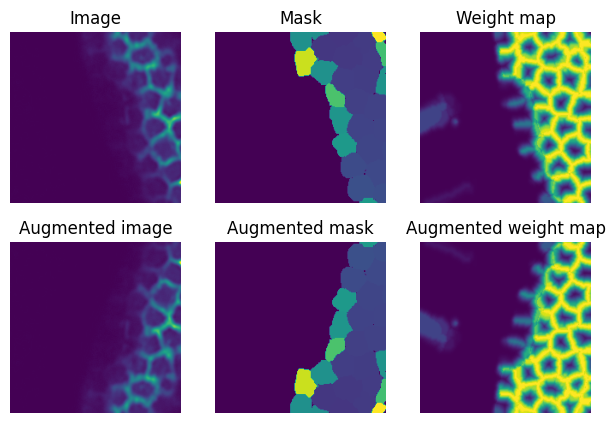

In [7]:
# Flip

augmentor = aug.Flip(p=1)

aug_data = augmentor(**data, targets=list(data.keys()))

plot_fn(data, aug_data)

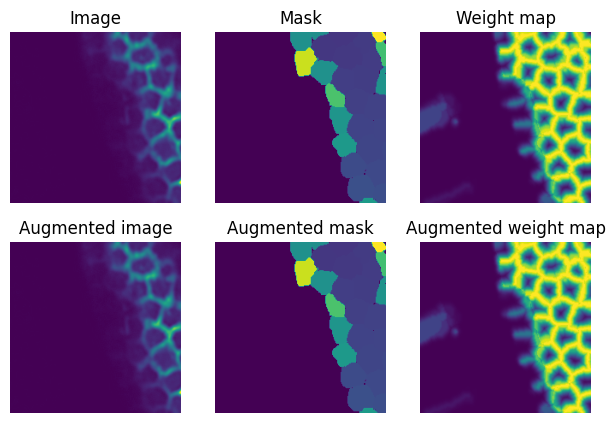

In [8]:
# Blur

augmentor = aug.RandomGuassianBlur(sigma_range=[0, 5], p=1)

aug_data = augmentor(**data, targets=list(data.keys()))

plot_fn(data, aug_data)

running apply (1, 24, 200, 200)
running apply to mask (24, 200, 200)
running apply to wmap (24, 200, 200)


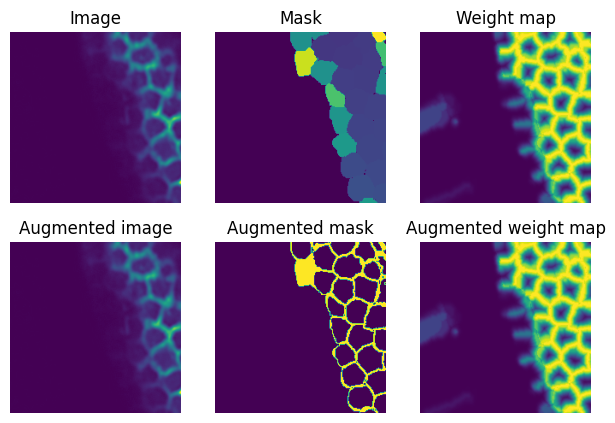

In [9]:
# LabelsToEdges

augmentor = aug.LabelsToEdges(
    mode="inner", # Boundary mode
    connectivity=2 # Pixel connectivity to draw boundary
    )

aug_data = augmentor(**data, targets=[['image'], ['mask'], ["weight_map"]])

plot_fn(data, aug_data)

running apply (1, 24, 200, 200)
running apply to mask (24, 200, 200)
running apply to wmap (24, 200, 200)
running Edge Mask Wmap apply (1, 24, 200, 200)
running Edge Mask Wmap apply to mask (24, 200, 200)
running Edge Mask Wmap apply to wmap (24, 200, 200)
(24, 200, 200)


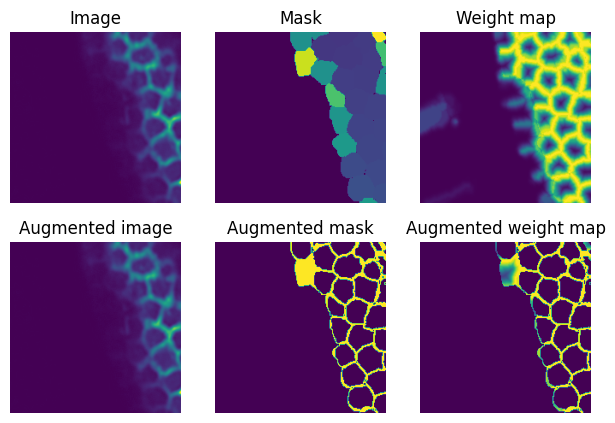

In [10]:
# Applying weightmap to masks

augmentor = aug.Compose(
    [
        aug.LabelsToEdges(mode="inner"),
        aug.EdgeMaskWmap(
            edge_multiplier=1, 
            wmap_multiplier=5, 
            invert_wmap=False
    )],
    targets=list(data.keys())
    )

aug_data = augmentor(**data)

plot_fn(data, aug_data)

running apply (1, 24, 200, 200)
running apply to mask (24, 200, 200)
running apply to wmap (24, 200, 200)
running Edge Mask Wmap apply (1, 24, 200, 200)
running Edge Mask Wmap apply to mask (24, 200, 200)
running Edge Mask Wmap apply to wmap (24, 200, 200)
(24, 200, 200)


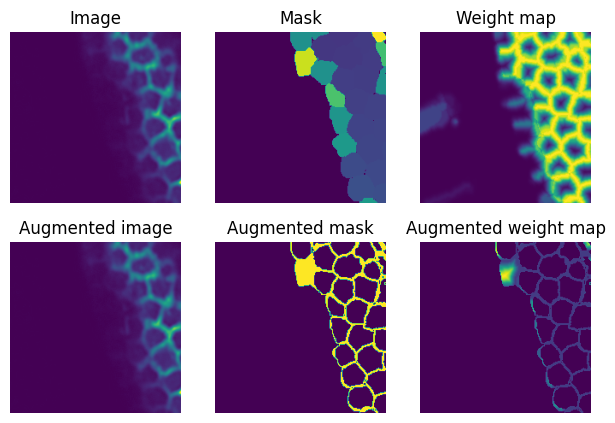

In [11]:
# Applying weightmap to masks

augmentor = aug.Compose(
    [
        aug.LabelsToEdges(mode="inner"),
        aug.EdgeMaskWmap(
            edge_multiplier=1, 
            wmap_multiplier=5, 
            invert_wmap=True
    )],
    targets=list(data.keys())
    )

aug_data = augmentor(**data)

plot_fn(data, aug_data)

running apply (1, 24, 200, 200)
running apply to mask (24, 200, 200)
running apply to wmap (24, 200, 200)


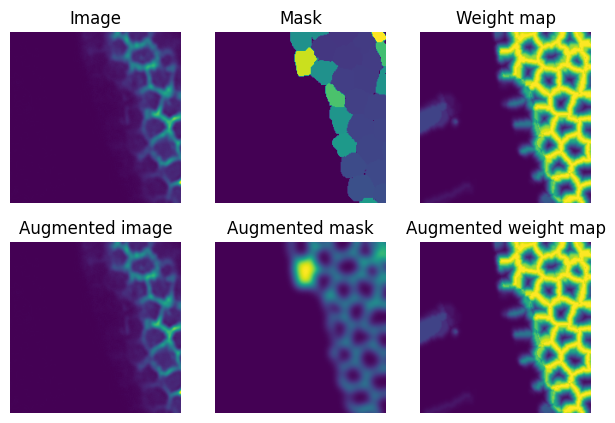

In [12]:
# BlurMasks

augmentor = aug.Compose(
    [
        aug.LabelsToEdges(mode="inner"),
        aug.BlurMasks(
            sigma=5
    )],
    targets=list(data.keys())
    )

aug_data = augmentor(**data)

plot_fn(data, aug_data)

labels shape: (24, 200, 200)
this label patch is not blank
cell_edges shape: (24, 200, 200)
foreground shape: (24, 200, 200)
labels function (24, 200, 200) (2, 24, 200, 200)
wmap shape (24, 200, 200) mask shape (1, 24, 200, 200)
(1, 24, 200, 200) (1, 24, 200, 200)


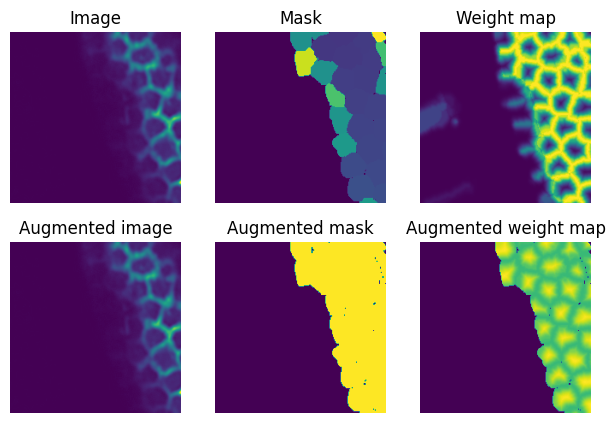

In [14]:
params = {
    "LabelsToEdges": {"connectivity": 2, "mode": "thick"},
    "EdgeMaskWmap": {"edge_multiplier":2, "wmap_multiplier":1, "invert_wmap":True},
    "LabelsToEdgesAndBinary": {"connectivity": 2, "mode": "thick","blur":2},
    "BinaryMaskWmap": {"edge_multiplier":2, "wmap_multiplier":1, "invert_wmap":True}}

augmentor = aug.Compose(
    [
        aug.LabelsToEdgesAndBinary(**params["LabelsToEdgesAndBinary"]),
        aug.BinaryMaskWmap(**params["BinaryMaskWmap"])],
    targets=list(data.keys())
    )

aug_data = augmentor(**data)

fig, ax = plt.subplots(2, 3, figsize=(7.5, 5))
z = 4
ax[0,0].imshow(data["image"][0,z,...])
ax[0,1].imshow(data["mask"][z,...])
ax[0,2].imshow(data["weight_map"][z,...])
ax[1,0].imshow(aug_data["image"][0,z,...])
ax[1,1].imshow(aug_data["mask"][z,...])
ax[1,2].imshow(aug_data["weight_map"][z,...])

ax[0,0].set_title("Image")
ax[0,1].set_title("Mask")
ax[0,2].set_title("Weight map")
ax[1,0].set_title("Augmented image")
ax[1,1].set_title("Augmented mask")
ax[1,2].set_title("Augmented weight map")

for _ax in ax.flatten():
    _ax.axis("off")


In [15]:
import argparse
import albumentations_3d.augmentations as aug

In [16]:
params = {
    "Normalize": {"per_channel": True},
    "RandomContrastBrightness": {"p": 0.5},
    "Flip": {"p": 0.5},
    "RandomRot90": {"p": 0.5, "channel_axis": 0},
    "RandomGuassianBlur": {"p": 0.5},
    "RandomGaussianNoise": {"p": 0.5},
    "RandomPoissonNoise": {"p": 0.5},
    "ElasticDeform": {"sigma": 10, "p": 0.5, "channel_axis": 0, "mode": "mirror"},
    "LabelsToEdgesAndBinary": {"connectivity": 2, "mode": "thick", "blur": 2},
    "BinaryMaskWmap": {"edge_multiplier": 2, "wmap_multiplier": 1, "invert_wmap": True},
    "ToTensor": {}
}

augmentor = aug.Compose(
    [   aug.Normalize(**params["Normalize"]),#last transform shape:(1, 24, 200, 200)
        aug.RandomContrastBrightness(**params["RandomContrastBrightness"]),
        aug.Flip(**params["Flip"]),
        aug.RandomRot90(**params["RandomRot90"]),
        aug.RandomGuassianBlur(**params["RandomGuassianBlur"]),
        aug.RandomGaussianNoise(**params["RandomGaussianNoise"]),
        aug.RandomPoissonNoise(**params["RandomPoissonNoise"]),#last transform shape:(1, 24, 200, 200)
        aug.ElasticDeform(**params["ElasticDeform"]), #last transform shape:(1, 24, 200, 200)
        aug.LabelsToEdgesAndBinary(**params["LabelsToEdgesAndBinary"]), #  last transform shape:(1, 24, 200, 200) 
        aug.BinaryMaskWmap(**params["BinaryMaskWmap"]),
        ],
    targets=list(data.keys())
    )

aug_data = augmentor(**data)
transform_shape_mask = aug_data['mask'].shape
transform_shape_weightmap = aug_data["weight_map"].shape
transform_shape_image = aug_data["image"].shape

print(f'last transform shape image:{transform_shape_image}')
print(f'last transform shape mask:{transform_shape_mask}')
print(f'last transform shape weight_map:{transform_shape_weightmap}')


""" fig, ax = plt.subplots(2, 3, figsize=(7.5, 5))
z = 4
ax[0,0].imshow(data["image"][0,z,...])
ax[0,1].imshow(data["mask"][z,...])
ax[0,2].imshow(data["weight_map"][z,...])
ax[1,0].imshow(aug_data["image"][0,z,...])
ax[1,1].imshow(aug_data["mask"][1,z,...])
ax[1,2].imshow(aug_data["weight_map"][1,z,...])

ax[0,0].set_title("Image")
ax[0,1].set_title("Mask")
ax[0,2].set_title("Weight map")
ax[1,0].set_title("Augmented image")
ax[1,1].set_title("Augmented mask")
ax[1,2].set_title("Augmented weight map")

for _ax in ax.flatten():
    _ax.axis("off") 

 """

labels shape: (24, 200, 200)
this label patch is not blank
cell_edges shape: (24, 200, 200)
foreground shape: (24, 200, 200)
labels function (24, 200, 200) (2, 24, 200, 200)
wmap shape (24, 200, 200) mask shape (1, 24, 200, 200)
(1, 24, 200, 200) (1, 24, 200, 200)
last transform shape image:(1, 24, 200, 200)
last transform shape mask:(24, 200, 200)
last transform shape weight_map:(24, 200, 200)


' fig, ax = plt.subplots(2, 3, figsize=(7.5, 5))\nz = 4\nax[0,0].imshow(data["image"][0,z,...])\nax[0,1].imshow(data["mask"][z,...])\nax[0,2].imshow(data["weight_map"][z,...])\nax[1,0].imshow(aug_data["image"][0,z,...])\nax[1,1].imshow(aug_data["mask"][1,z,...])\nax[1,2].imshow(aug_data["weight_map"][1,z,...])\n\nax[0,0].set_title("Image")\nax[0,1].set_title("Mask")\nax[0,2].set_title("Weight map")\nax[1,0].set_title("Augmented image")\nax[1,1].set_title("Augmented mask")\nax[1,2].set_title("Augmented weight map")\n\nfor _ax in ax.flatten():\n    _ax.axis("off") \n\n '